In [ ]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("rushilprajapati/data-final")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 2.32G/2.32G [01:48<00:00, 23.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/rushilprajapati/data-final/versions/1
Contents of base_path (/root/.cache/kagglehub/datasets/rushilprajapati/data-final/versions):
['1']
Contents of path (/root/.cache/kagglehub/datasets/rushilprajapati/data-final/versions/1):
['data']


In [ ]:
import os

# Path to 'data' folder
data_folder_path = os.path.join(path, 'data')

if os.path.exists(data_folder_path):
    contents = os.listdir(data_folder_path)
    print(f"Contents in 'data' folder ({data_folder_path}):")
    display(contents)

    # Deeper check for subdirectories
    for item in contents[:5]: # Check the first 5 items
        item_path = os.path.join(data_folder_path, item)
        if os.path.isdir(item_path):
            print(f"\nSubfolder '{item}' contains: {os.listdir(item_path)[:10]}...")
else:
    print("Data folder not found.")

Contents in 'data' folder (/root/.cache/kagglehub/datasets/rushilprajapati/data-final/versions/1/data):


['Non-scientific',
 'Macroscopy',
 'FACS',
 'Microscopy',
 'Histopathology',
 'Blot-Gel']


Subfolder 'Non-scientific' contains: ['image_5959.jpg', 'image_1880.jpg', 'image_851.jpg', 'image_5771.jpg', 'image_5737.jpg', 'image_791.jpg', 'image_4162.jpg', 'image_2744.jpg', 'image_900.jpg', 'image_5508.jpg']...

Subfolder 'Macroscopy' contains: ['ISIC_0026923.jpg', 'NORMAL2-IM-0807-0001.jpeg', '050103.png', '91b51883-f013-4844-bb89-58e3fdf52621.jpg', 'a89f9bb4-7ade-49cf-91aa-31eb2d218226.jpg', 'c1d280f4-18fb-4d2e-a361-9787ea093e6f.jpg', 'ISIC_0027435.jpg', 'e20b3577-81fd-4769-8d46-6ed02727ffa2.jpg', '1-3-46-670589-33-1-63716506118773221000001-5491402665325019197_png_jpg.rf.1d5d457a46fef3973127a1618f75d693.jpg', '050306.png']...

Subfolder 'FACS' contains: ['050103.png', '030107 (3).png', '060102 (7).png', '040004 (7).png', '020002 (7).png', '030003 (10).png', '010102 (2).png', '060107 (2).png', '040000 (16).png', '030001 (8).png']...

Subfolder 'Microscopy' contains: ['050103.png', '050002 (14).png', '050306.png', '040004 (7).png', '020002 (7).png', '010040.png', '060701.png', 

In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Set source and destination paths
source_dir = data_folder_path
base_split_dir = '/content/dataset_split'
train_dir = os.path.join(base_split_dir, 'train')
test_dir = os.path.join(base_split_dir, 'test')

# Create train/test directories
for d in [train_dir, test_dir]:
    if not os.path.exists(d):
        os.makedirs(d)

# Get list of classes (subfolders in 'data')
classes = [d for d in os.listdir(source_dir) if os.path.isdir(os.path.join(source_dir, d))]

for cls in classes:
    cls_source_path = os.path.join(source_dir, cls)

    # Create subfolders for each class in train and test
    os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(test_dir, cls), exist_ok=True)

    # Get list of all image files
    images = [f for f in os.listdir(cls_source_path) if os.path.isfile(os.path.join(cls_source_path, f))]

    if len(images) > 0:
        # Split with 8/2 ratio
        train_imgs, test_imgs = train_test_split(images, test_size=0.2, random_state=42)

        # Copy files to respective directories
        for img in train_imgs:
            shutil.copy(os.path.join(cls_source_path, img), os.path.join(train_dir, cls, img))
        for img in test_imgs:
            shutil.copy(os.path.join(cls_source_path, img), os.path.join(test_dir, cls, img))

        print(f"Class '{cls}': {len(train_imgs)} train images, {len(test_imgs)} test images.")

print("\nDataset split completed at:", base_split_dir)

Class 'Non-scientific': 4008 train images, 1002 test images.
Class 'Macroscopy': 3569 train images, 893 test images.
Class 'FACS': 856 train images, 214 test images.
Class 'Microscopy': 1207 train images, 302 test images.
Class 'Histopathology': 4143 train images, 1036 test images.
Class 'Blot-Gel': 1500 train images, 375 test images.

Dataset split completed at: /content/dataset_split


In [ ]:
import torch

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
else:
    print("GPU not detected. Training will be slow on CPU.")

Using device: cuda
GPU Name: Tesla T4


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader

# Data transformations
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Loading datasets
image_datasets = {
    'train': datasets.ImageFolder(train_dir, data_transforms['train']),
    'test': datasets.ImageFolder(test_dir, data_transforms['test'])
}

dataloaders = {
    'train': DataLoader(image_datasets['train'], batch_size=32, shuffle=True, num_workers=2),
    'test': DataLoader(image_datasets['test'], batch_size=32, shuffle=False, num_workers=2)
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'test']}
class_names = image_datasets['train'].classes

# Load pre-trained VGG16 and modify the final layer
model = models.vgg16(weights='IMAGENET1K_V1')
for param in model.features.parameters():
    param.requires_grad = False  # Freeze feature layers

num_ftrs = model.classifier[6].in_features
model.classifier[6] = nn.Linear(num_ftrs, len(class_names))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)

# Training Loop
num_epochs = 10
history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

for epoch in range(num_epochs):
    print(f'Epoch {epoch+1}/{num_epochs}')

    for phase in ['train', 'test']:
        if phase == 'train':
            model.train()
        else:
            model.eval()

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloaders[phase]:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / dataset_sizes[phase]
        epoch_acc = running_corrects.double() / dataset_sizes[phase]

        history[f'{phase}_loss'].append(epoch_loss)
        history[f'{phase}_acc'].append(epoch_acc.item())

        print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 164MB/s]


Epoch 1/10
train Loss: 0.7399 Acc: 0.9493
test Loss: 0.3553 Acc: 0.9819
Epoch 2/10
train Loss: 0.6977 Acc: 0.9764
test Loss: 0.5159 Acc: 0.9817
Epoch 3/10
train Loss: 0.8159 Acc: 0.9827
test Loss: 0.7092 Acc: 0.9885
Epoch 4/10
train Loss: 0.8412 Acc: 0.9869
test Loss: 0.9122 Acc: 0.9890
Epoch 5/10
train Loss: 0.4567 Acc: 0.9914
test Loss: 1.4613 Acc: 0.9851
Epoch 6/10
train Loss: 0.8810 Acc: 0.9901
test Loss: 4.2842 Acc: 0.9778
Epoch 7/10
train Loss: 0.9142 Acc: 0.9922
test Loss: 1.1267 Acc: 0.9929
Epoch 8/10
train Loss: 1.2018 Acc: 0.9920
test Loss: 1.3790 Acc: 0.9908
Epoch 9/10
train Loss: 1.1068 Acc: 0.9937
test Loss: 2.2423 Acc: 0.9919
Epoch 10/10
train Loss: 0.6800 Acc: 0.9956
test Loss: 3.3480 Acc: 0.9903


In [ ]:
print("--- Training Summary ---")
final_train_acc = history['train_acc'][-1]
final_test_acc = history['test_acc'][-1]
print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Test Accuracy: {final_test_acc:.4f}")
print(f"Best Test Accuracy achieved: {max(history['test_acc']):.4f}")

--- Training Summary ---
Final Training Accuracy: 0.9956
Final Test Accuracy: 0.9903
Best Test Accuracy achieved: 0.9929


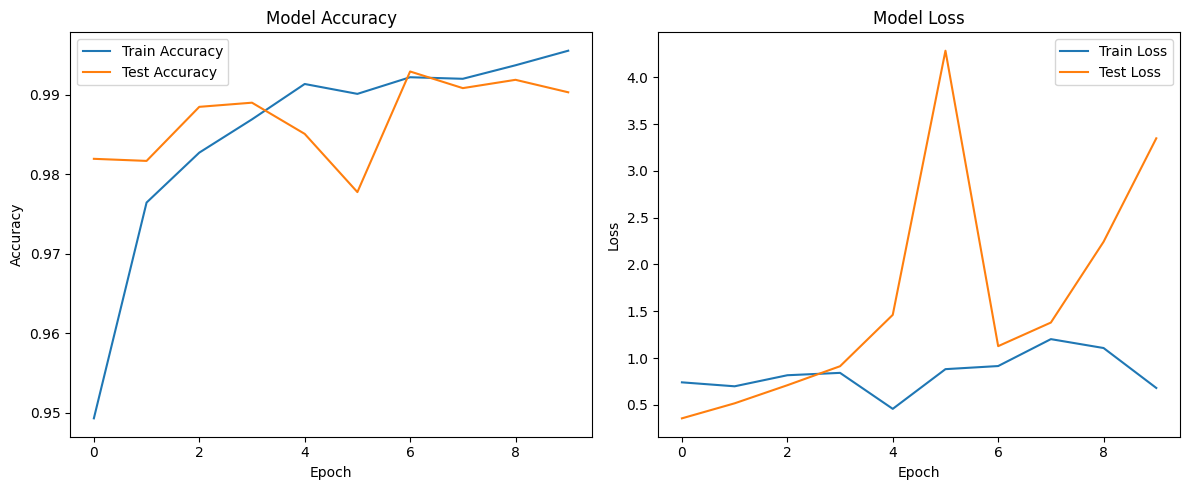

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['test_acc'], label='Test Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['test_loss'], label='Test Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()